Extended inventory analysis using multi-dimensional ABC-XYZ matrix.

In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set();

In [53]:
engine = create_engine('mssql+pyodbc://@LAPTOP/AdventureWorksDW2025?driver=SQL+Server&Trusted_Connection=yes')

query = """
SELECT 
    CustomerKey, 
    DueDate, 
    SalesAmount, 
    SalesOrderNumber, 
    OrderQuantity, 
    EnglishProductName 
FROM dbo.FactInternetSales f
JOIN dbo.DimProduct p ON f.ProductKey = p.ProductKey
WHERE YEAR(DueDate) > 2011
"""

df = pd.read_sql_query(query, engine)

In [23]:
df.dtypes

CustomerKey                    int64
DueDate               datetime64[us]
SalesAmount                  float64
SalesOrderNumber                 str
OrderQuantity                  int64
EnglishProductName               str
dtype: object

In [24]:
df.isna().any()

CustomerKey           False
DueDate               False
SalesAmount           False
SalesOrderNumber      False
OrderQuantity         False
EnglishProductName    False
dtype: bool

In [55]:
df.columns = ['cust_key', 'date', 'sales_amount', 'order_count', 'quantity', 'product_n']

In [4]:
df['date'] = pd.to_datetime(df['date']).dt.normalize()

ABC analysis

In [86]:
sales_by_prod = df.groupby('product_n').agg({'sales_amount': sum})
share_of_sales = (sales_by_prod['sales_amount'] / sum(sales_by_prod['sales_amount']))
share_of_sales = share_of_sales.sort_values(ascending=False)

cumulative_share = share_of_sales.cumsum().reset_index()
cumulative_share['ABC'] = np.where(cumulative_share['sales_amount'] < 0.8, 'A', np.where(cumulative_share['sales_amount'] < 0.95, 'B', 'C'))

abc_df = cumulative_share.reset_index() 
cumulative_share

,product_n,sales_amount,ABC
0,"Mountain-200 Black, 46",0.061026,A
1,"Mountain-200 Black, 42",0.121594,A
2,"Mountain-200 Silver, 38",0.181109,A
3,"Mountain-200 Silver, 46",0.238920,A
4,"Mountain-200 Black, 38",0.296454,A
...,...,...,...
124,"Mountain-100 Silver, 48",0.999473,C
125,"Mountain-100 Black, 42",0.999623,C
126,"Mountain-100 Black, 44",0.999773,C
127,"Racing Socks, M",0.999892,C


In [20]:
abc_counts = cumulative_share['abc'].value_counts()

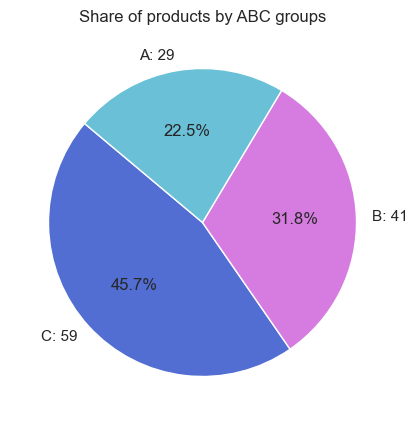

In [95]:
labels = [f'{label}: {value}' for label, value in abc_counts.items()]

plt.figure(figsize=(5, 5))
plt.pie(
    abc_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140,    
    colors=["#526ED2", "#D67CE0", "#6AC1D7"] 
)

plt.title('Share of products by ABC groups')
plt.show()

XYZ analysis

In [81]:
df['date'] = pd.to_datetime(df['date'])
monthly_sales = df.groupby([df['date'].dt.to_period('M'), 'product_n'])['order_count'].nunique().unstack(fill_value=0)

stats = pd.DataFrame(index=monthly_sales.columns)
stats['mean'] = monthly_sales.mean()
stats['std'] = monthly_sales.std()

stats['cv'] = stats['std'] / stats['mean']
stats['XYZ'] = pd.qcut(stats['cv'], q=[0, 0.33, 0.66, 1.0], labels=['X', 'Y', 'Z'])


result = stats[['cv', 'XYZ']].reset_index()
result = result.sort_values(by=['XYZ', 'cv'], ascending=[True, True])

stats_df = stats.reset_index()
result


,product_n,cv,XYZ
68,"Road-250 Red, 58",0.411584,X
64,"Road-250 Black, 58",0.426389,X
62,"Road-250 Black, 48",0.439531,X
61,"Road-250 Black, 44",0.443553,X
63,"Road-250 Black, 52",0.475562,X
...,...,...,...
24,"Mountain-100 Black, 38",5.099020,Z
27,"Mountain-100 Black, 48",5.099020,Z
29,"Mountain-100 Silver, 42",5.099020,Z
59,"Road-150 Red, 56",5.099020,Z


In [94]:
xyz_counts = result['XYZ'].value_counts()

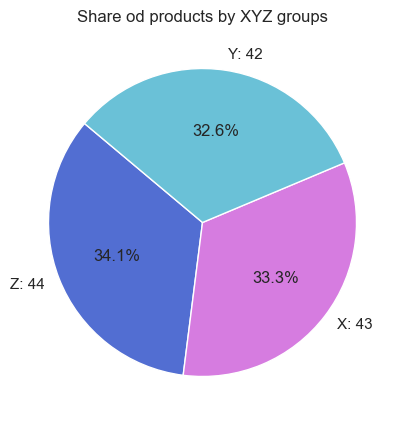

In [96]:
labels = [f'{label}: {value}' for label, value in xyz_counts.items()]

plt.figure(figsize=(5, 5))
plt.pie(
    xyz_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140,    
    colors=["#526ED2", "#D67CE0", "#6AC1D7"] 
)

plt.title('Share od products by XYZ groups')
plt.show()

ABC и XYZ in a bundle

In [98]:
final_analysis = abc_df.merge(stats_df[['product_n', 'XYZ']], on='product_n')
final_analysis['ABC_XYZ'] = final_analysis['ABC'].astype(str) + final_analysis['XYZ'].astype(str)

final_analysis[['product_n', 'ABC', 'XYZ', 'ABC_XYZ']]

,product_n,ABC,XYZ,ABC_XYZ
0,"Mountain-200 Black, 46",A,X,AX
1,"Mountain-200 Black, 42",A,X,AX
2,"Mountain-200 Silver, 38",A,X,AX
3,"Mountain-200 Silver, 46",A,X,AX
4,"Mountain-200 Black, 38",A,X,AX
...,...,...,...,...
124,"Mountain-100 Silver, 48",C,Z,CZ
125,"Mountain-100 Black, 42",C,Z,CZ
126,"Mountain-100 Black, 44",C,Z,CZ
127,"Racing Socks, M",C,Y,CY


In [93]:
abc_xyz_counts = final_analysis['ABC_XYZ'].value_counts()
abc_xyz_counts

ABC_XYZ
CZ    23
CX    22
BY    18
BZ    16
AX    14
CY    14
AY    10
BX     7
AZ     5
Name: count, dtype: int64